In [1]:
# Import pandas for working with data
import pandas as pd

# Load the Carvana dataset
df = pd.read_csv("../data/raw/carvana.csv")

# Display the first five rows
df.head()

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990


In [2]:
# Display information about the dataset
df.info()

# Display the dataset shape
print("\nDataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    22000 non-null  str  
 1   Year    22000 non-null  int64
 2   Miles   22000 non-null  int64
 3   Price   22000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 687.6 KB

Dataset Shape: (22000, 4)

Column Names:
['Name', 'Year', 'Miles', 'Price']

Missing Values:
Name     0
Year     0
Miles    0
Price    0
dtype: int64


In [3]:
# Select the features and price column needed for this assignment
data = df[["Year", "Miles", "Price"]].copy()

# Display the first five rows
data.head()

,Year,Miles,Price
0,2018,41946,16990
1,2020,45328,23990
2,2012,81068,21590
3,2019,35372,21590
4,20173,68992,22990


In [4]:
# Check the minimum and maximum year
print("Minimum Year:", data["Year"].min())
print("Maximum Year:", data["Year"].max())

# Find suspicious year values
invalid_years = data[
    (data["Year"] < 1900) | (data["Year"] > 2026)
]

print("\nNumber of invalid year records:", len(invalid_years))

# Display some invalid records
invalid_years.head()

Minimum Year: 2009
Maximum Year: 20223500

Number of invalid year records: 2851


,Year,Miles,Price
4,20173,68992,22990
31,20194,24065,15990
34,20165,66644,18590
39,20133,100316,12990
46,2013500,44087,15990


In [5]:
# Check the minimum and maximum year
print("Minimum Year:", data["Year"].min())
print("Maximum Year:", data["Year"].max())

# Find suspicious year values
invalid_years = data[
    (data["Year"] < 1900) | (data["Year"] > 2026)
]

print("\nNumber of invalid year records:", len(invalid_years))

# Display some invalid records
invalid_years.head()

Minimum Year: 2009
Maximum Year: 20223500

Number of invalid year records: 2851


,Year,Miles,Price
4,20173,68992,22990
31,20194,24065,15990
34,20165,66644,18590
39,20133,100316,12990
46,2013500,44087,15990


In [6]:
# Display all rows with invalid years
print("Invalid Year Records:")
print(invalid_years)

Invalid Year Records:
          Year   Miles  Price
4        20173   68992  22990
31       20194   24065  15990
34       20165   66644  18590
39       20133  100316  12990
46     2013500   44087  15990
...        ...     ...    ...
21952    20151   35706  22990
21963    20165   42003  22590
21970    20123   89624  13990
21975    20151   35706  22990
21981    20155   31686  21990

[2851 rows x 3 columns]


In [7]:
# Remove records with invalid year values
data_clean = data[
    (data["Year"] >= 1900) & (data["Year"] <= 2026)
].copy()

# Check the new dataset size
print("Original dataset size:", data.shape)
print("Cleaned dataset size:", data_clean.shape)

# Confirm that no invalid years remain
print("\nInvalid years remaining:",
      ((data_clean["Year"] < 1900) | (data_clean["Year"] > 2026)).sum())

Original dataset size: (22000, 3)
Cleaned dataset size: (19149, 3)

Invalid years remaining: 0


In [8]:
# Examine the price column
print("Price Statistics:")
print(data_clean["Price"].describe())


Price Statistics:
count     19149.000000
mean      20290.062510
std        6044.864185
min       10990.000000
25%       16590.000000
50%       18990.000000
75%       22590.000000
max      102990.000000
Name: Price, dtype: float64


In [9]:
# Remove records with invalid year values
data_clean = data[
    (data["Year"] >= 1900) & (data["Year"] <= 2026)
].copy()

# Check the original and cleaned dataset sizes
print("Original dataset size:", data.shape)
print("Cleaned dataset size:", data_clean.shape)

# Confirm that no invalid years remain
print("\nInvalid years remaining:",
      ((data_clean["Year"] < 1900) | (data_clean["Year"] > 2026)).sum())

Original dataset size: (22000, 3)
Cleaned dataset size: (19149, 3)

Invalid years remaining: 0


In [10]:
# Examine the price column
print("Price Statistics:")
print(data_clean["Price"].describe())

Price Statistics:
count     19149.000000
mean      20290.062510
std        6044.864185
min       10990.000000
25%       16590.000000
50%       18990.000000
75%       22590.000000
max      102990.000000
Name: Price, dtype: float64


In [11]:
# Calculate the 75th percentile of car prices
price_threshold = data_clean["Price"].quantile(0.75)

print("Premium Price Threshold:", price_threshold)

# Create the Premium classification target
# 1 = Premium, 0 = Regular
data_clean["Premium"] = (
    data_clean["Price"] >= price_threshold
).astype(int)

# Display the first five rows
data_clean.head()

Premium Price Threshold: 22590.0


,Year,Miles,Price,Premium
0,2018,41946,16990,0
1,2020,45328,23990,1
2,2012,81068,21590,0
3,2019,35372,21590,0
5,2019,47973,18590,0


In [12]:
# Count Regular and Premium cars
print("Class Distribution:")
print(data_clean["Premium"].value_counts())

# Show the percentage of each class
print("\nClass Percentage:")
print(data_clean["Premium"].value_counts(normalize=True) * 100)

Class Distribution:
Premium
0    14202
1     4947
Name: count, dtype: int64

Class Percentage:
Premium
0    74.165753
1    25.834247
Name: proportion, dtype: float64


In [13]:
# Define the input features
X = data_clean[["Year", "Miles"]]

# Define the target variable
y = data_clean["Premium"]

# Display the features
print("Features (X):")
print(X.head())

# Display the target
print("\nTarget (y):")
print(y.head())

Features (X):
   Year  Miles
0  2018  41946
1  2020  45328
2  2012  81068
3  2019  35372
5  2019  47973

Target (y):
0    0
1    1
2    0
3    0
5    0
Name: Premium, dtype: int64


In [14]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes of each dataset
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (15319, 2)
Testing features: (3830, 2)
Training target: (15319,)
Testing target: (3830,)


In [15]:
# Check class distribution in the training data
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTraining Class Percentage:")
print(y_train.value_counts(normalize=True) * 100)

# Check class distribution in the testing data
print("\nTesting Class Distribution:")
print(y_test.value_counts())

print("\nTesting Class Percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training Class Distribution:
Premium
0    11361
1     3958
Name: count, dtype: int64

Training Class Percentage:
Premium
0    74.162804
1    25.837196
Name: proportion, dtype: float64

Testing Class Distribution:
Premium
0    2841
1     989
Name: count, dtype: int64

Testing Class Percentage:
Premium
0    74.177546
1    25.822454
Name: proportion, dtype: float64


In [16]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the testing data
X_test_scaled = scaler.transform(X_test)

# Display the first five scaled training rows
print("First five scaled training rows:")
print(X_train_scaled[:5])

First five scaled training rows:
[[ 0.94612212 -1.08258005]
 [-2.05822636  0.90630005]
 [ 0.27848912  1.58056948]
 [-0.72296037  1.58846156]
 [ 0.94612212 -0.15305618]]


In [17]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [18]:
# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Display the first 20 predictions
print("First 20 Predictions:")
print(y_pred[:20])

# Display the corresponding actual values
print("\nFirst 20 Actual Values:")
print(y_test.iloc[:20].values)

First 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0]

First 20 Actual Values:
[0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0]


In [19]:
# Calculate the probability of being Premium
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 probabilities
print("First 10 Premium Probabilities:")
print(y_prob[:10])

First 10 Premium Probabilities:
[0.04756807 0.0586405  0.38161346 0.09600005 0.02349274 0.12622454
 0.04764388 0.20727099 0.25792234 0.0114278 ]


In [20]:
# Calculate the probability of being Premium
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 probabilities
print("First 10 Premium Probabilities:")
print(y_prob[:10])

First 10 Premium Probabilities:
[0.04756807 0.0586405  0.38161346 0.09600005 0.02349274 0.12622454
 0.04764388 0.20727099 0.25792234 0.0114278 ]


In [21]:
# Import classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display the results
print("Classification Metrics")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Classification Metrics
----------------------
Accuracy : 0.8174934725848564
Precision: 0.7059659090909091
Recall   : 0.5025278058645096
F1-Score : 0.5871234494979327
ROC-AUC  : 0.8303647407651004


In [22]:
# Import confusion_matrix
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2634  207]
 [ 492  497]]


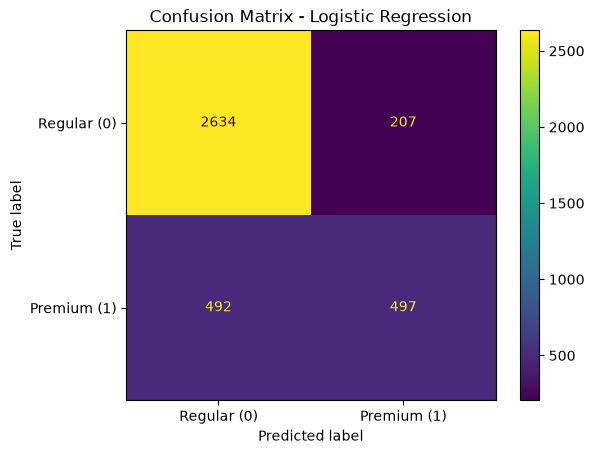

In [23]:
# Import matplotlib and ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Regular (0)", "Premium (1)"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [24]:
# Display the confusion matrix values clearly
tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 2634
False Positive (FP): 207
False Negative (FN): 492
True Positive (TP): 497


In [25]:
# Import classification_report
from sklearn.metrics import classification_report

# Generate the classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Regular", "Premium"]
))

Classification Report:
              precision    recall  f1-score   support

     Regular       0.84      0.93      0.88      2841
     Premium       0.71      0.50      0.59       989

    accuracy                           0.82      3830
   macro avg       0.77      0.71      0.73      3830
weighted avg       0.81      0.82      0.81      3830



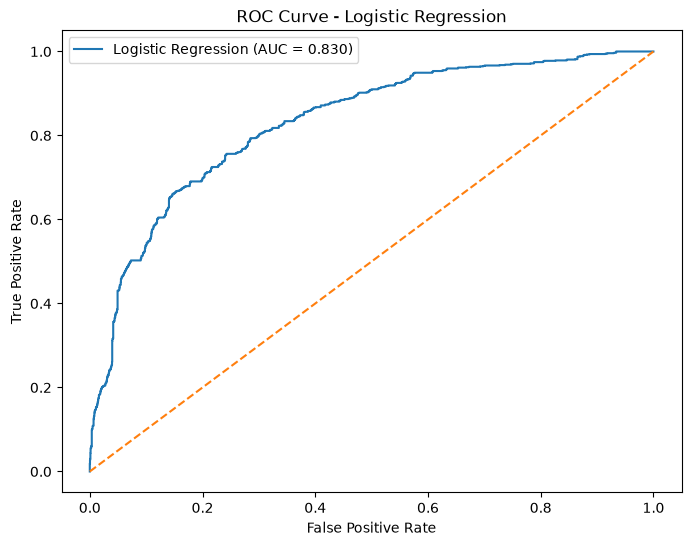

In [26]:
# Import ROC curve
from sklearn.metrics import roc_curve

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")

# Plot the random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [27]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [28]:
# Make predictions with Random Forest
rf_pred = rf_model.predict(X_test)

# Get Premium probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

# Display Random Forest results
print("Random Forest Metrics")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Metrics
---------------------
Accuracy : 0.9112271540469974
Precision: 0.8390804597701149
Recall   : 0.8119312436804853
F1-Score : 0.8252826310380267
ROC-AUC  : 0.9269222980415688


In [29]:
# Compare the two classification models
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

print("Model Comparison:")
print(results)

Model Comparison:
      Metric  Logistic Regression  Random Forest
0   Accuracy             0.817493       0.911227
1  Precision             0.705966       0.839080
2     Recall             0.502528       0.811931
3   F1-Score             0.587123       0.825283
4    ROC-AUC             0.830365       0.926922


In [30]:
# Calculate the Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[2687  154]
 [ 186  803]]


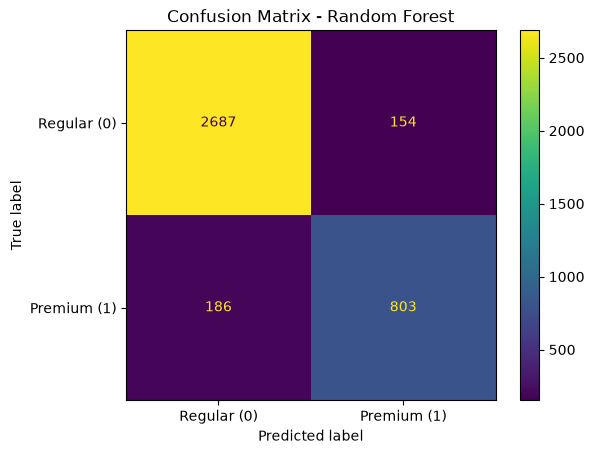

In [31]:
# Display the Random Forest confusion matrix
rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Regular (0)", "Premium (1)"]
)

rf_disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [32]:
# Get feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
  Feature  Importance
1   Miles    0.776498
0    Year    0.223502


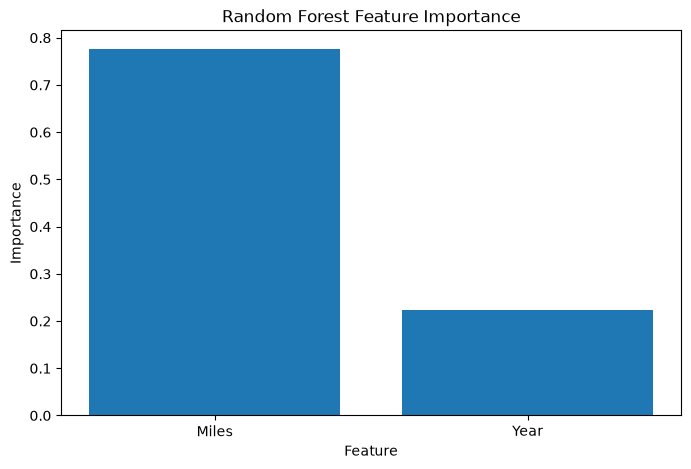

In [33]:
# Plot feature importance
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [34]:
# Identify the best model based on F1-Score
if rf_f1 > f1:
    best_model = "Random Forest"
    best_score = rf_f1
else:
    best_model = "Logistic Regression"
    best_score = f1

print("Best Model:", best_model)
print("Best F1-Score:", best_score)

Best Model: Random Forest
Best F1-Score: 0.8252826310380267


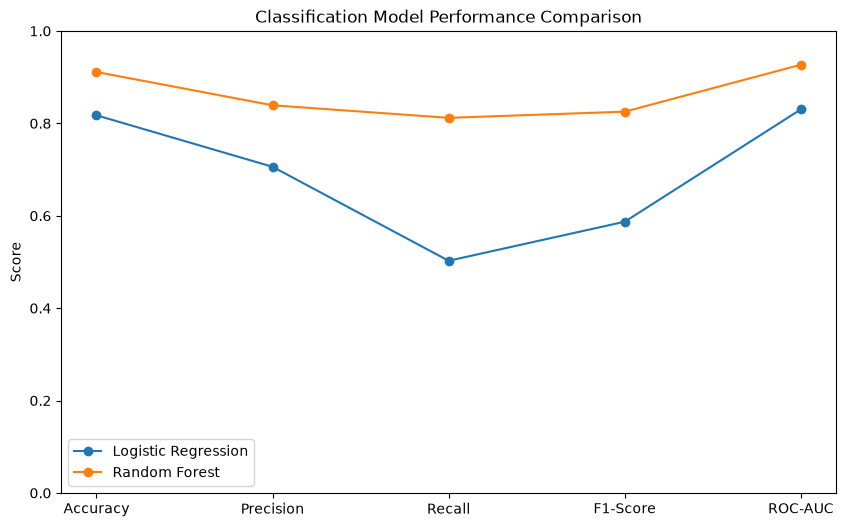

In [35]:
# Plot model performance comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

logistic_scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

rf_scores = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_roc_auc
]

x = range(len(metrics))

plt.figure(figsize=(10, 6))

plt.plot(x, logistic_scores, marker="o", label="Logistic Regression")
plt.plot(x, rf_scores, marker="o", label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Classification Model Performance Comparison")
plt.legend()
plt.ylim(0, 1)
plt.show()

# Final Conclusion

In this classification task, car prices were converted into a binary target variable called Premium, where cars in the highest 25% of the price distribution were classified as Premium (1), while the remaining cars were classified as Regular (0). Invalid year values were identified and removed before modelling.

Two classification algorithms, Logistic Regression and Random Forest, were trained and evaluated using Accuracy, Precision, Recall, F1-Score and ROC-AUC. The models were trained using Year and Miles as input features, while Price was excluded from the features to prevent data leakage.

The model with the stronger overall performance based on the evaluation metrics was selected as the preferred classifier. The results demonstrate how machine learning can be used to classify vehicles into Premium and Regular categories based on available vehicle characteristics.